# Exploratory Data Analysis — FinanceBench (Task T04)

Profiles the 150-example open-source FinanceBench QA set that drives our RAG-hallucination
study, and produces the publication-quality figures for the **Data** section of the paper.

**Inputs** (run `python src/download_data.py` first):
- `data/raw/financebench_open_source.jsonl` — 150 QA records
- `data/raw/financebench_document_information.jsonl` — document metadata

**Outputs** (saved to `results/`):
- `fig_eda_overview.png` — 4-panel summary (the paper's Figure 1 candidate)
- `fig_question_types.png`, `fig_reasoning_types.png`, `fig_doc_types.png`,
  `fig_sectors.png`, `fig_answer_length.png`
- `eda_summary.md` — the written findings for the paper

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Resolve repo root whether run from notebooks/ or repo root.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data" / "raw"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"
PALETTE = "viridis"
print("repo root:", ROOT)

repo root: /Users/bhalchandra/SEM3_NEU/NLP/project/finrag-hallucination


## 1. Load + merge

In [2]:
qa = pd.read_json(DATA / "financebench_open_source.jsonl", lines=True)
doc = pd.read_json(DATA / "financebench_document_information.jsonl", lines=True)

# Derived length features
qa["answer_words"] = qa["answer"].astype(str).str.split().str.len()
qa["question_words"] = qa["question"].astype(str).str.split().str.len()

print(f"QA records: {len(qa)}")
print(f"Unique companies: {qa['company'].nunique()}")
print(f"Unique source documents: {qa['doc_name'].nunique()}")
print(f"Doc periods (fiscal years): {qa['doc_period'].min()}-{qa['doc_period'].max()}")
qa[["company", "doc_type", "question_type", "question_reasoning", "answer_words"]].head()

QA records: 150
Unique companies: 32
Unique source documents: 84
Doc periods (fiscal years): 2015-2024


,company,doc_type,question_type,question_reasoning,answer_words
0,3M,10k,metrics-generated,Information extraction,1
1,3M,10k,metrics-generated,Information extraction,1
2,3M,10k,domain-relevant,Logical reasoning (based on numerical reasoning),30
3,3M,10k,domain-relevant,Logical reasoning (based on numerical reasonin...,40
4,3M,10k,novel-generated,None,7


## 2. Distributions

Each helper saves a standalone figure and prints the underlying counts.

In [3]:
def bar(series, title, xlabel, fname, order=None, rotate=0):
    counts = series.value_counts()
    if order is not None:
        counts = counts.reindex(order).dropna()
    else:
        counts = counts.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(x=counts.index, y=counts.values, palette=PALETTE, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# questions")
    if rotate:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha="right")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(int(v)), ha="center", va="bottom", fontsize=11)
    fig.tight_layout()
    fig.savefig(RESULTS / fname)
    plt.show()
    print(counts.to_dict())
    return counts

/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_61401/3225476670.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=PALETTE, ax=ax)
/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_61401/3225476670.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha="right")


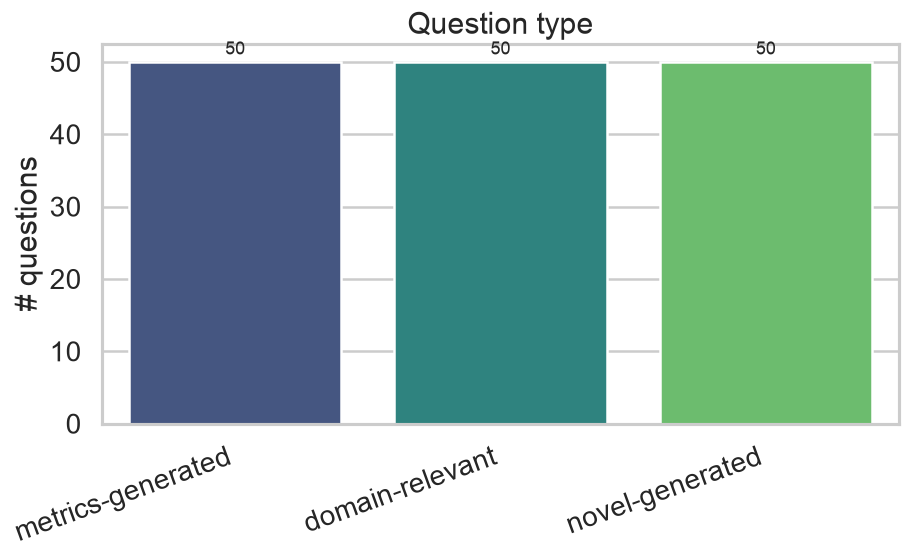

{'metrics-generated': 50, 'domain-relevant': 50, 'novel-generated': 50}


question_type
metrics-generated    50
domain-relevant      50
novel-generated      50
Name: count, dtype: int64

In [4]:
# Question type — the FinanceBench design split (balanced 50/50/50)
bar(qa["question_type"], "Question type", "", "fig_question_types.png", rotate=20)

/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_61401/3225476670.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=PALETTE, ax=ax)
/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_61401/3225476670.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha="right")


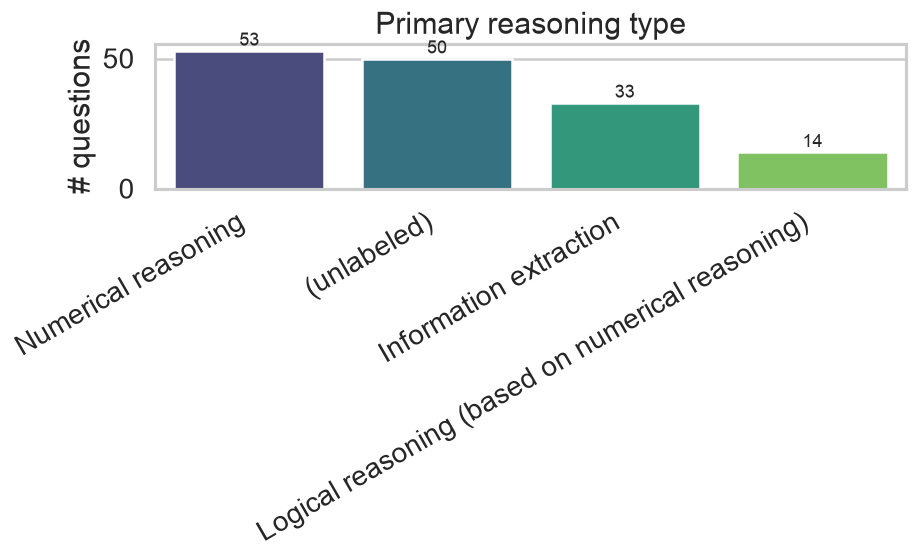

{'Numerical reasoning': 53, '(unlabeled)': 50, 'Information extraction': 33, 'Logical reasoning (based on numerical reasoning)': 14}


question_reasoning
Numerical reasoning                                 53
(unlabeled)                                         50
Information extraction                              33
Logical reasoning (based on numerical reasoning)    14
Name: count, dtype: int64

In [5]:
# Reasoning type — what cognitive demand the question places on the model.
# Numerical reasoning dominates, which is exactly where RAG tends to hallucinate.
reasoning = qa["question_reasoning"].fillna("(unlabeled)").str.split(" OR ").str[0]
bar(reasoning, "Primary reasoning type", "", "fig_reasoning_types.png", rotate=30)

/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_61401/3225476670.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=PALETTE, ax=ax)


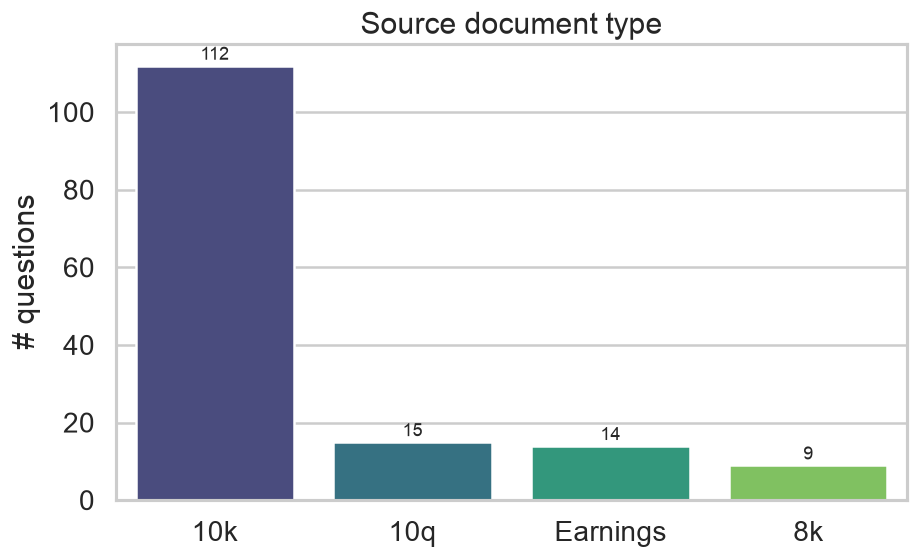

/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_61401/3225476670.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=PALETTE, ax=ax)
/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_61401/3225476670.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha="right")


{'10k': 112, '10q': 15, 'Earnings': 14, '8k': 9}


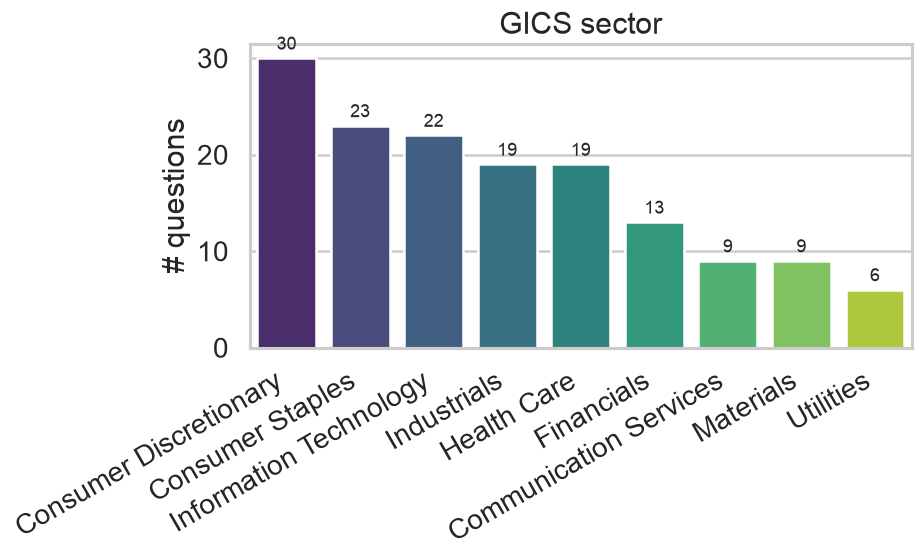

{'Consumer Discretionary': 30, 'Consumer Staples': 23, 'Information Technology': 22, 'Industrials': 19, 'Health Care': 19, 'Financials': 13, 'Communication Services': 9, 'Materials': 9, 'Utilities': 6}


gics_sector
Consumer Discretionary    30
Consumer Staples          23
Information Technology    22
Industrials               19
Health Care               19
Financials                13
Communication Services     9
Materials                  9
Utilities                  6
Name: count, dtype: int64

In [6]:
bar(qa["doc_type"], "Source document type", "", "fig_doc_types.png")
bar(qa["gics_sector"], "GICS sector", "", "fig_sectors.png", rotate=30)

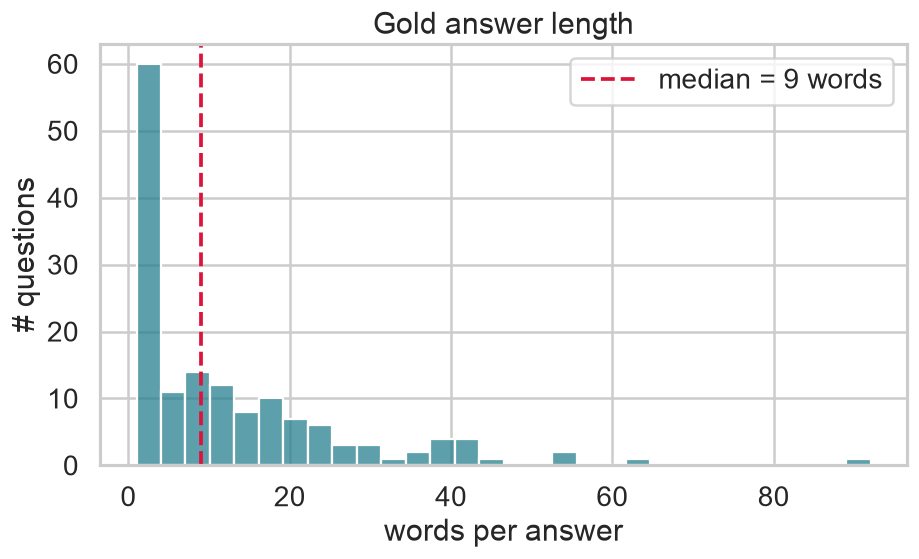

count    150.0
mean      12.7
std       14.8
min        1.0
25%        1.0
50%        9.0
75%       19.0
max       92.0
Name: answer_words, dtype: float64

In [7]:
# Answer length — most gold answers are short, which makes F1/EM meaningful
# but also makes a single hallucinated number flip an answer from right to wrong.
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(qa["answer_words"], bins=30, color=sns.color_palette(PALETTE)[2], ax=ax)
ax.axvline(qa["answer_words"].median(), color="crimson", ls="--",
           label=f"median = {qa['answer_words'].median():.0f} words")
ax.set_title("Gold answer length")
ax.set_xlabel("words per answer")
ax.set_ylabel("# questions")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "fig_answer_length.png")
plt.show()
qa["answer_words"].describe().round(1)

## 3. Paper Figure 1 — 4-panel overview

/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_61401/2244011132.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=qt.index, y=qt.values, palette=PALETTE, ax=axes[0, 0])
/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_61401/2244011132.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=20, ha="right")
/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_61401/2244011132.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rc.values, y=rc.index, palette=PALETTE, ax=axes[0, 1

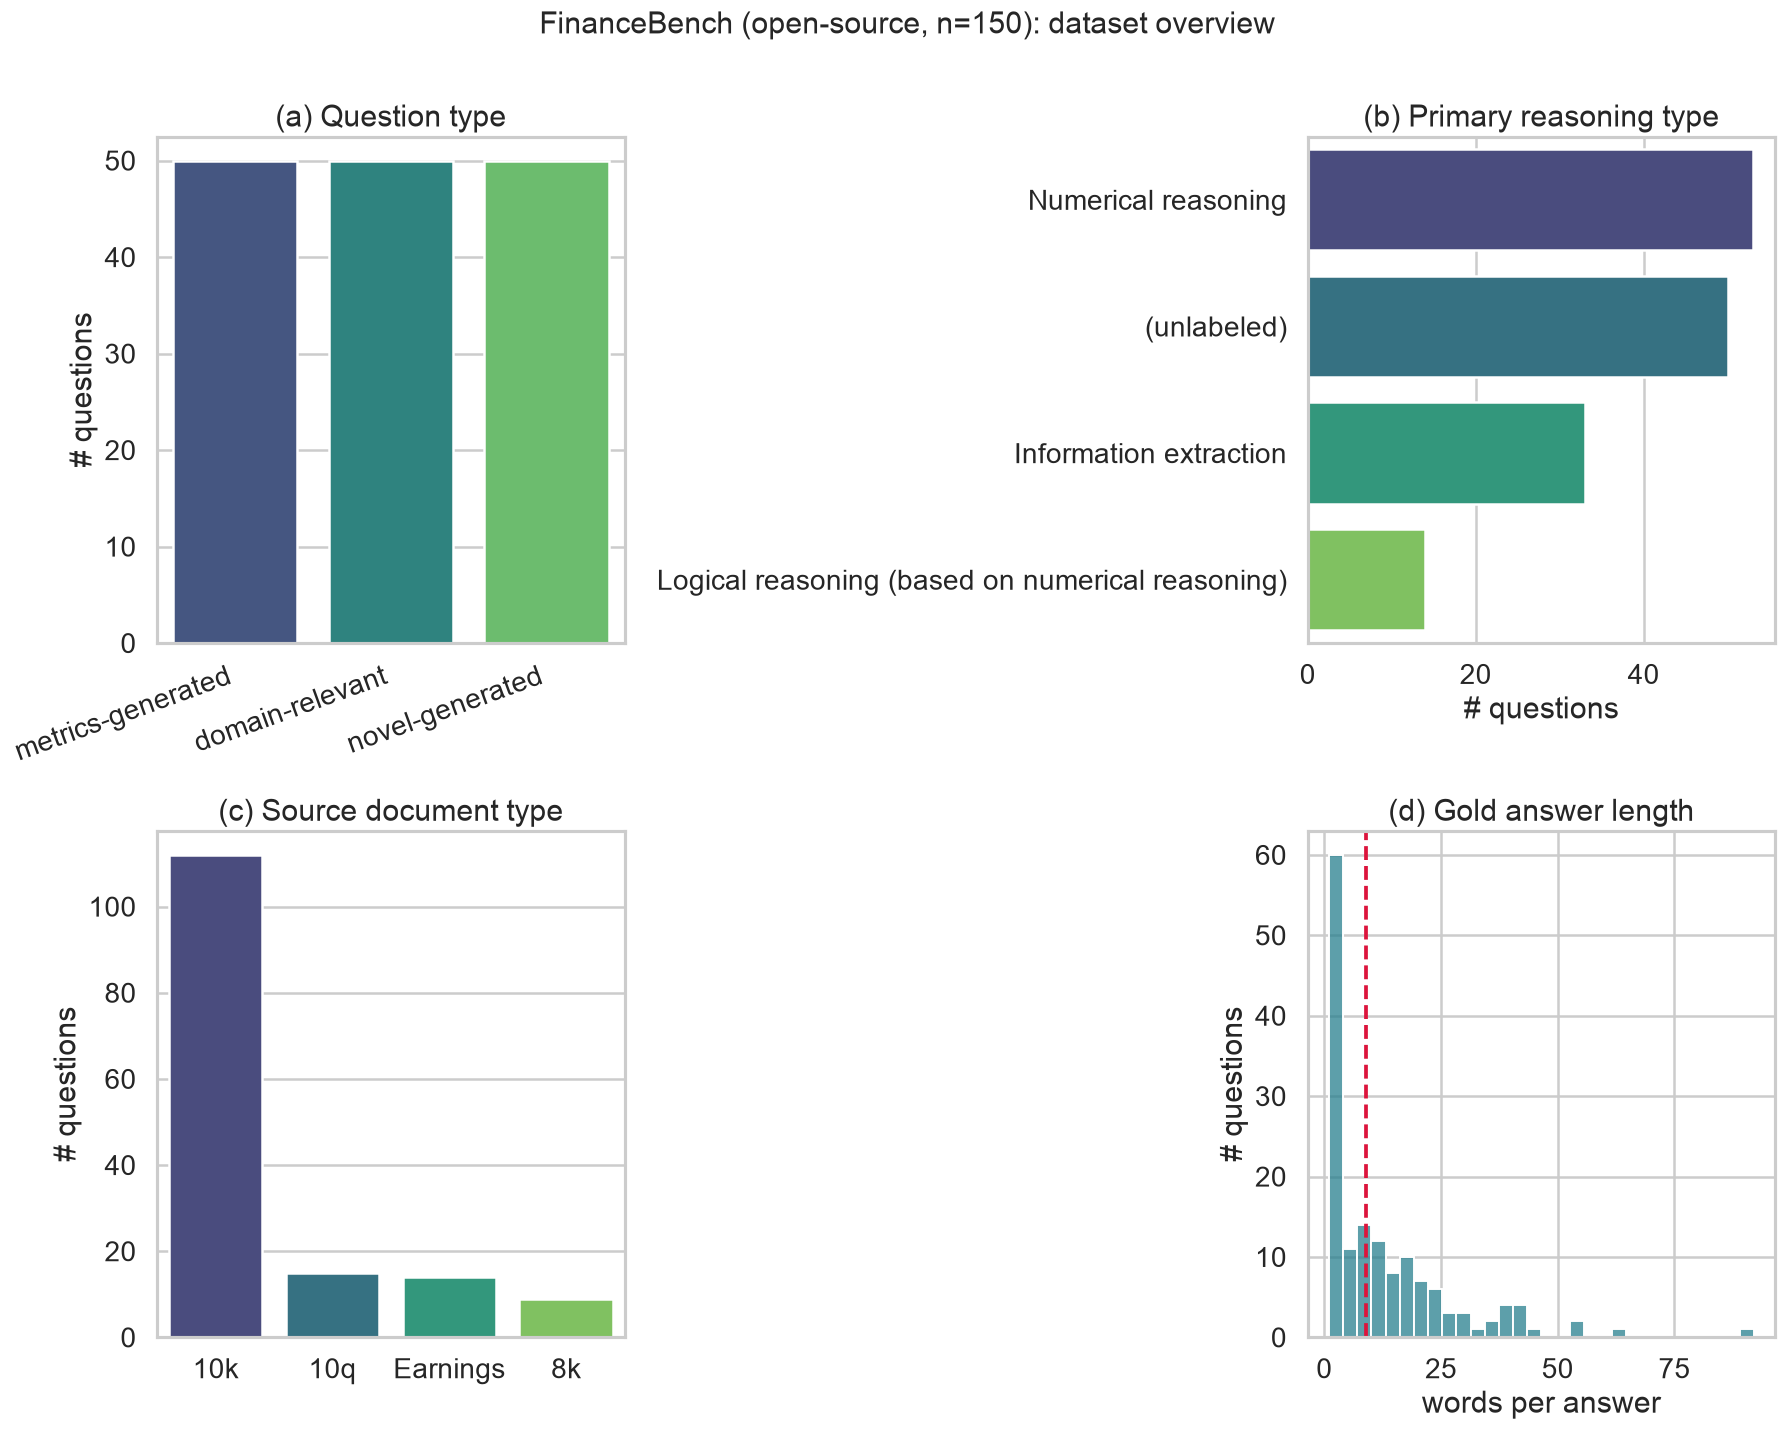

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

qt = qa["question_type"].value_counts()
sns.barplot(x=qt.index, y=qt.values, palette=PALETTE, ax=axes[0, 0])
axes[0, 0].set_title("(a) Question type")
axes[0, 0].set_ylabel("# questions"); axes[0, 0].set_xlabel("")
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=20, ha="right")

rc = reasoning.value_counts()
sns.barplot(x=rc.values, y=rc.index, palette=PALETTE, ax=axes[0, 1], orient="h")
axes[0, 1].set_title("(b) Primary reasoning type")
axes[0, 1].set_xlabel("# questions"); axes[0, 1].set_ylabel("")

dt = qa["doc_type"].value_counts()
sns.barplot(x=dt.index, y=dt.values, palette=PALETTE, ax=axes[1, 0])
axes[1, 0].set_title("(c) Source document type")
axes[1, 0].set_ylabel("# questions"); axes[1, 0].set_xlabel("")

sns.histplot(qa["answer_words"], bins=30, color=sns.color_palette(PALETTE)[2], ax=axes[1, 1])
axes[1, 1].axvline(qa["answer_words"].median(), color="crimson", ls="--")
axes[1, 1].set_title("(d) Gold answer length")
axes[1, 1].set_xlabel("words per answer"); axes[1, 1].set_ylabel("# questions")

fig.suptitle("FinanceBench (open-source, n=150): dataset overview", fontsize=18, y=1.0)
fig.tight_layout()
fig.savefig(RESULTS / "fig_eda_overview.png")
plt.show()

## 4. Written summary for the paper

Writes `results/eda_summary.md` so the Data section text lives in the repo, not just here.

In [9]:
n = len(qa)
qt = qa["question_type"].value_counts()
dt = qa["doc_type"].value_counts()
sec = qa["gics_sector"].value_counts()
rc = reasoning.value_counts()

summary = f"""# EDA Summary — FinanceBench (open-source, n={n})

_Auto-generated by `notebooks/01_eda.ipynb` (Task T04). Figures saved under `results/`._

## Dataset at a glance
- **{n} QA pairs** spanning **{qa['company'].nunique()} companies** and
  **{qa['doc_name'].nunique()} source filings**, fiscal years
  **{qa['doc_period'].min()}-{qa['doc_period'].max()}**.
- Every record carries gold `answer`, `evidence` (supporting passage), and `justification`,
  so groundedness can be judged directly.

## Key distributions
- **Question type** is balanced by design: {', '.join(f'{k} ({v})' for k, v in qt.items())}.
- **Reasoning type** is skewed toward computation: {', '.join(f'{k} ({v})' for k, v in rc.head(4).items())}.
  Numerical reasoning is the single largest demand - the regime where RAG most often
  hallucinates (a wrong figure looks fluent but is unsupported).
- **Source documents**: {', '.join(f'{k} ({v})' for k, v in dt.items())}. 10-K annual reports
  dominate, so retrieval operates over long, structured filings.
- **Sectors** span {qa['gics_sector'].nunique()} GICS sectors, led by
  {', '.join(f'{k} ({v})' for k, v in sec.head(3).items())}.
- **Answer length** is short (median {qa['answer_words'].median():.0f} words,
  mean {qa['answer_words'].mean():.1f}); questions are longer
  (median {qa['question_words'].median():.0f} words). Short gold answers make token-level
  F1/EM informative, but also mean a single fabricated number flips a correct answer to wrong.

## Why this matters for our study
The mix - numeric-heavy questions, long 10-K source documents, and terse exact-value answers -
is precisely the setting where retrieval-augmented generation is prone to *grounded-but-wrong*
outputs. This motivates measuring faithfulness (RAGAS) alongside F1/EM, and our 4-category
hallucination taxonomy (numerical, entity, reasoning, unsupported extrapolation).
"""

(RESULTS / "eda_summary.md").write_text(summary)
print(summary)

# EDA Summary — FinanceBench (open-source, n=150)

_Auto-generated by `notebooks/01_eda.ipynb` (Task T04). Figures saved under `results/`._

## Dataset at a glance
- **150 QA pairs** spanning **32 companies** and
  **84 source filings**, fiscal years
  **2015-2024**.
- Every record carries gold `answer`, `evidence` (supporting passage), and `justification`,
  so groundedness can be judged directly.

## Key distributions
- **Question type** is balanced by design: metrics-generated (50), domain-relevant (50), novel-generated (50).
- **Reasoning type** is skewed toward computation: Numerical reasoning (53), (unlabeled) (50), Information extraction (33), Logical reasoning (based on numerical reasoning) (14).
  Numerical reasoning is the single largest demand - the regime where RAG most often
  hallucinates (a wrong figure looks fluent but is unsupported).
- **Source documents**: 10k (112), 10q (15), Earnings (14), 8k (9). 10-K annual reports
  dominate, so retrieval operates over long, str